In [3]:
import csv
import os
import pickle
import time
import yaml
from collections import defaultdict
from operator import itemgetter
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.profiler import ProfilerActivity, profile, record_function
from torch.utils.data import DataLoader, Dataset
from TKG import ReadableTKG, TemporalKnowledgeGraph, Quadruple
from torch_geometric.nn.conv import MessagePassing
from tqdm import tqdm

import pytorch_lightning as pl
import utils
from logger import Logger

# Dataset

In [5]:
class TKGDataset(Dataset):
    def __init__(self, dataset="YAGO", mode="train", history_len=5, dilate_len=1, add_inverse=True):
        super().__init__()
        self.dataset_name = dataset
        self.mode = mode
        self.history_len = history_len
        self.dilate_len = dilate_len

        self.data_path = os.path.join("./data", dataset)
        self.num_nodes, self.raw_num_rels, self.num_times = utils.get_total_number(self.data_path, "stat.txt")
        data, _ = utils.load_quadruples(self.data_path, f"{mode}.txt")

        quadruples = [Quadruple(int(r[0]), int(r[1]), int(r[2]), int(r[3])) for r in data]

        self.graph = TemporalKnowledgeGraph(
            quadruples=quadruples,
            num_nodes=self.num_nodes,
            num_rels=self.raw_num_rels,
            add_inverse=add_inverse
        )
        self.num_rels = self.graph.num_rels
        self.times = list(range(self.graph.num_snapshots))

    def __len__(self):
        return len(self.times) - self.history_len * self.dilate_len

    def __getitem__(self, idx):
        idx += self.history_len * self.dilate_len
        history = self.graph.get_history(idx=idx, history_len=self.history_len, dilate_len=self.dilate_len)
        target = self.graph.get_snapshot(idx)
        target_quads = self.graph.get_quadruples_at(idx)  # [E, 4]
        return history, target, target_quads

    def collate_fn(self, batch):
        histories, targets, target_quads = zip(*batch)
        return list(histories), list(targets), list(target_quads)

    def get_loader(self, batch_size=1, num_workers=0):
        return DataLoader(
            self,
            batch_size=batch_size,
            shuffle=(self.mode == "train"),
            num_workers=num_workers,
            collate_fn=self.collate_fn
        )

    def stat(self):
        return self.graph.stat(f"{self.dataset_name}-{self.mode}")

    def __str__(self):
        return self.stat()

    def __repr__(self):
        return self.stat()

# Trainer

In [6]:
class Trainer:
    def __init__(self, model: torch.nn.Module, logger, model_config: dict, train_config: dict, dataset_config: dict, ent_weight: float = 0.3, rel_weight: float = 0.7, device: Optional[torch.device] = None):
        self.model = model
        self.logger = logger
        self.model_config = model_config
        self.train_config = train_config
        self.dataset_config = dataset_config
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.ent_loss_fn = torch.nn.CrossEntropyLoss()
        self.rel_loss_fn = torch.nn.CrossEntropyLoss()

        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=train_config["lr"], weight_decay=train_config["weight_decay"])

        self.num_epochs = train_config["max_epochs"]
        self.ent_weight = ent_weight
        self.rel_weight = rel_weight

        self.save_dir = logger.get_log_dir()
        self.chkpt_dir = os.path.join(self.save_dir, "chkpt")
        os.makedirs(self.chkpt_dir, exist_ok=True)

        self.epoch_losses: list[float] = []
        self.val_losses: list[float] = []

        self.model.to(self.device)

    def _compute_loss(self, ent_score, rel_score, quads) -> torch.Tensor:
        ent_loss = self.ent_loss_fn(ent_score, quads[:, 2])
        rel_loss = self.rel_loss_fn(rel_score, quads[:, 1])
        return self.ent_weight * ent_loss + self.rel_weight * rel_loss

    def _train_step(self, history_graphs, target_quads) -> float:
        self.optimizer.zero_grad()

        history_graph = history_graphs[0]
        quads = target_quads[0].to(self.device).long()

        ent_score, rel_score = self.model(history_graph, quads)
        loss = self._compute_loss(ent_score, rel_score, quads)

        loss.backward()
        self.optimizer.step()

        return loss.item()

    def _eval_step(self, history_graphs, target_quads) -> float:
        history_graph = history_graphs[0]
        quads = target_quads[0].to(self.device).long()

        ent_score, rel_score = self.model(history_graph, quads)
        loss = self._compute_loss(ent_score, rel_score, quads)

        return loss.item()

    def _run_epoch(self, loader, desc: str, train: bool) -> float:
        total_loss = 0.0
        num_batches = 0

        if train:
            self.model.train()
            for history_graphs, target_graph, target_quads in tqdm(loader, desc=desc, leave=False):
                total_loss += self._train_step(history_graphs, target_quads)
                num_batches += 1
        else:
            self.model.eval()
            with torch.no_grad():
                for history_graphs, target_graph, target_quads in tqdm(loader, desc=desc, leave=False):
                    total_loss += self._eval_step(history_graphs, target_quads)
                    num_batches += 1

        return total_loss / max(num_batches, 1)

    def _profile_flops(self, loader) -> Optional[float]:
        try:
            batch = next(iter(loader))
            history_graphs, target_graph, target_quads = batch

            history_graph = history_graphs[0]
            quads = target_quads[0].to(self.device).long()

            activities = [ProfilerActivity.CPU]

            if self.device.type == "cuda":
                activities.append(ProfilerActivity.CUDA)

            self.model.eval()

            with torch.no_grad():
                with profile(activities=activities, with_flops=True, record_shapes=True) as prof:
                    with record_function("model_inference"):
                        self.model(history_graph, quads)

            total_flops = sum(e.flops for e in prof.key_averages() if e.flops > 0)
            return total_flops / 1e9

        except Exception as e:
            self.logger.log("ERROR", f"[FLOPs] Could not measure FLOPs: {e}")
            return None

    def _measure_peak_vram(self, loader) -> Optional[float]:
        if self.device.type != "cuda":
            return None

        try:
            batch = next(iter(loader))
            history_graphs, target_graph, target_quads = batch

            history_graph = history_graphs[0]
            quads = target_quads[0].to(self.device).long()

            torch.cuda.reset_peak_memory_stats(self.device)

            self.model.eval()

            with torch.no_grad():
                self.model(history_graph, quads)

            return torch.cuda.max_memory_allocated(self.device) / 1e9

        except Exception as e:
            self.logger.log("ERROR", f"[VRAM] Could not measure peak VRAM: {e}")
            return None

    def log_efficiency_stats(self, loader) -> None:
        self.logger.log("SETUP", "[Efficiency Stats]")

        peak_vram = self._measure_peak_vram(loader)

        if peak_vram is not None:
            self.logger.log("SETUP", f"  Peak VRAM (single batch): {peak_vram:.4f} GB")
        else:
            self.logger.log("SETUP", "  Peak VRAM: N/A (CPU mode)")

        gflops = self._profile_flops(loader)

        if gflops is not None:
            self.logger.log("SETUP", f"  FLOPs (single forward pass): {gflops:.4f} GFLOPs")
        else:
            self.logger.log("SETUP", "  FLOPs: N/A")

    def save_configs(self) -> None:
        config = {
            "model": self.model_config,
            "training": self.train_config,
            "dataset": self.dataset_config,
        }

        path = os.path.join(self.save_dir, "config.yaml")

        with open(path, "w") as f:
            yaml.dump(config, f, default_flow_style=False, sort_keys=False)

        self.logger.log_config(self.model_config, self.train_config, self.dataset_config)
        self.logger.log("SAVE", f"Config saved to {path}")

    def _log_vram(self, tag: str) -> None:
        if self.device.type == "cuda":
            peak_vram = torch.cuda.max_memory_allocated(self.device) / 1e9
            reserved_vram = torch.cuda.memory_reserved(self.device) / 1e9
            self.logger.log_vram(f"{tag} Peak VRAM: {peak_vram:.4f} GB | {tag} Reserved VRAM: {reserved_vram:.4f} GB")

    def fit(self, train_loader, val_loader=None) -> dict[str, list[float]]:
        best_val_loss = float("inf")
        train_times: list[float] = []
        val_times: list[float] = []

        for epoch in range(1, self.num_epochs + 1):
            if self.device.type == "cuda":
                torch.cuda.reset_peak_memory_stats(self.device)

            t0 = time.time()
            train_loss = self._run_epoch(train_loader, desc=f"[{epoch}/{self.num_epochs}] Train", train=True)
            train_time = time.time() - t0

            self.epoch_losses.append(train_loss)
            train_times.append(train_time)

            self.logger.log_train_epoch(epoch, train_loss, train_time)
            self._log_vram("Train")

            val_loss = None

            if val_loader is not None:
                if self.device.type == "cuda":
                    torch.cuda.reset_peak_memory_stats(self.device)

                t0 = time.time()
                val_loss = self._run_epoch(val_loader, desc=f"[{epoch}/{self.num_epochs}] Val", train=False)
                val_time = time.time() - t0

                self.val_losses.append(val_loss)
                val_times.append(val_time)

                self.logger.log_val_epoch(epoch, val_loss, val_time)
                self._log_vram("Validation")

                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    self.save_checkpoint("best.pt")

            self.logger.log_metrics(epoch, train_loss, val_loss)

        self.save_checkpoint("final.pt")
        self.logger.log_training_completed()

        avg_train_loss = sum(self.epoch_losses) / len(self.epoch_losses)
        avg_train_time = sum(train_times) / len(train_times)

        self.logger.log("INFO", f"Avg Train Loss: {avg_train_loss:.6f} | Avg Train Time: {avg_train_time:.2f}s")

        if self.val_losses:
            avg_val_loss = sum(self.val_losses) / len(self.val_losses)
            avg_val_time = sum(val_times) / len(val_times)
            self.logger.log("VAL", f"Avg Val Loss: {avg_val_loss:.6f} | Avg Val Time: {avg_val_time:.2f}s")

        return {"train": self.epoch_losses, "val": self.val_losses}

    def test(self, test_loader) -> float:
        if self.device.type == "cuda":
            torch.cuda.reset_peak_memory_stats(self.device)

        t0 = time.time()
        test_loss = self._run_epoch(test_loader, desc="Test", train=False)
        test_time = time.time() - t0

        self.logger.log_test(test_loss, test_time)
        self._log_vram("Test")

        return test_loss

    def save_checkpoint(self, filename: str) -> None:
        path = os.path.join(self.chkpt_dir, filename)

        torch.save({
            "model_state_dict": self.model.state_dict(),
            "optimizer_state_dict": self.optimizer.state_dict(),
            "epoch_losses": self.epoch_losses,
            "val_losses": self.val_losses,
        }, path)

        self.logger.log_checkpoint_saved(path)

    def load_checkpoint(self, path: str) -> None:
        checkpoint = torch.load(path, map_location=self.device)

        self.model.load_state_dict(checkpoint["model_state_dict"])
        self.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

        self.epoch_losses = checkpoint.get("epoch_losses", [])
        self.val_losses = checkpoint.get("val_losses", [])

        self.logger.log_checkpoint_loaded(path)

# Model

In [7]:
class RGCNConv(MessagePassing):
    def __init__(self, in_channels, out_channels, num_relations, num_bases):
        super().__init__(aggr="mean")
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.num_relations = num_relations
        self.num_bases = num_bases

        self.basis = nn.Parameter(torch.empty(num_bases, in_channels, out_channels))
        self.att = nn.Parameter(torch.empty(num_relations, num_bases))
        self.root = nn.Parameter(torch.empty(in_channels, out_channels))
        self.bias = nn.Parameter(torch.empty(out_channels))
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.basis)
        nn.init.xavier_uniform_(self.att)
        nn.init.xavier_uniform_(self.root)
        nn.init.zeros_(self.bias)

    def forward(self, x, edge_index, edge_type, edge_norm=None, size=None):
        weight = torch.einsum("rb,bio->rio", self.att, self.basis)
        return self.propagate(edge_index, size=size, x=x, weight=weight, edge_type=edge_type, edge_norm=edge_norm)

    def message(self, x_j, edge_type, weight, edge_norm):
        if x_j is None:
            raise NotImplementedError("Featureless mode is not supported.")

        out = torch.einsum("ei,eio->eo", x_j, weight[edge_type])
        if edge_norm is not None:
            out = out * edge_norm.unsqueeze(-1)
        return out

    def update(self, aggr_out, x):
        if x is not None:
            out = aggr_out + x @ self.root
        else:
            out = aggr_out + self.root.sum(dim=0)
        out = out + self.bias
        return out

    def __repr__(self):
        return f"{self.__class__.__name__}({self.in_channels}, {self.out_channels}, num_relations={self.num_relations})"

In [8]:
class ConvTransBase(torch.nn.Module):
    def __init__(self, num_b, embedding_dim, input_dropout=0, hidden_dropout=0, feature_map_dropout=0, channels=50, kernel_size=3):
        super().__init__()
        self.inp_drop = torch.nn.Dropout(input_dropout)
        self.hidden_drop = torch.nn.Dropout(hidden_dropout)
        self.feature_map_drop = torch.nn.Dropout(feature_map_dropout)
        self.loss = torch.nn.BCELoss()
        self.conv1 = torch.nn.Conv1d(2, channels, kernel_size, stride=1, padding=kernel_size // 2)
        self.bn0 = torch.nn.BatchNorm1d(2)
        self.bn1 = torch.nn.BatchNorm1d(channels)
        self.bn2 = torch.nn.BatchNorm1d(embedding_dim)
        self.register_parameter('b', nn.Parameter(torch.zeros(num_b)))
        self.fc = torch.nn.Linear(embedding_dim * channels, embedding_dim)

    def conv_pipeline(self, x, batch_size):
        x = self.inp_drop(self.bn0(x))
        x = self.feature_map_drop(F.relu(self.bn1(self.conv1(x))))
        x = self.hidden_drop(self.fc(x.view(batch_size, -1)))
        x = F.relu(self.bn2(x) if batch_size > 1 else x)
        return x


class ConvTransR(ConvTransBase):
    def __init__(self, num_relations, embedding_dim, input_dropout=0, hidden_dropout=0, feature_map_dropout=0, channels=50, kernel_size=3):
        super().__init__(num_relations * 2, embedding_dim, input_dropout, hidden_dropout, feature_map_dropout, channels, kernel_size)

    def forward(self, embedding, emb_rel, triplets):
        e1_embedded_all = F.tanh(embedding)
        e1 = e1_embedded_all[triplets[:, 0]].unsqueeze(1)
        e2 = e1_embedded_all[triplets[:, 2]].unsqueeze(1)
        x = self.conv_pipeline(torch.cat([e1, e2], 1), len(triplets))
        return torch.mm(x, emb_rel.transpose(1, 0))


class ConvTransE(ConvTransBase):
    def __init__(self, num_entities, embedding_dim, input_dropout=0, hidden_dropout=0, feature_map_dropout=0, channels=50, kernel_size=3):
        super().__init__(num_entities, embedding_dim, input_dropout, hidden_dropout, feature_map_dropout, channels, kernel_size)

    def forward(self, embedding, emb_rel, triplets, partial_embeding=None):
        e1_embedded_all = F.tanh(embedding)
        e1 = e1_embedded_all[triplets[:, 0]].unsqueeze(1)
        rel = emb_rel[triplets[:, 1]].unsqueeze(1)
        x = self.conv_pipeline(torch.cat([e1, rel], 1), len(triplets))
        target = e1_embedded_all if partial_embeding is None else partial_embeding
        return torch.mm(x, target.transpose(1, 0))

    def forward_slow(self, embedding, emb_rel, triplets):
        e1_embedded_all = F.tanh(embedding)
        e1 = e1_embedded_all[triplets[:, 0]].unsqueeze(1)
        rel = emb_rel[triplets[:, 1]].unsqueeze(1)
        x = self.conv_pipeline(torch.cat([e1, rel], 1), len(triplets))
        return torch.sum(torch.mul(x, e1_embedded_all[triplets[:, 2]]), dim=1)

In [19]:
class Model(nn.Module):
    def __init__(self, num_nodes: int, num_rels: int, embedding_dim: int, L: int, device: str = "cuda"):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_rels = num_rels
        self.embedding_dim = embedding_dim
        self.rel_embedding = nn.Parameter(torch.empty(num_rels, embedding_dim))
        self.ent_embedding = nn.Parameter(torch.empty(num_nodes, embedding_dim))
        # self.time_embedding = nn.Parameter(torch.empty(L, embedding_dim))
        self.L = L
        self.rgcn = nn.ModuleList([
			RGCNConv(embedding_dim, embedding_dim, num_rels, num_bases=20),
			RGCNConv(embedding_dim, embedding_dim, num_rels, num_bases=20),
			RGCNConv(embedding_dim, embedding_dim, num_rels, num_bases=20),
			RGCNConv(embedding_dim, embedding_dim, num_rels, num_bases=20),
			RGCNConv(embedding_dim, embedding_dim, num_rels, num_bases=20),
		])
        self.ent_decoder = ConvTransE(num_nodes, embedding_dim, input_dropout=0.1, hidden_dropout=0.1, feature_map_dropout=0.1, channels=embedding_dim, kernel_size=3)
        self.rel_decoder = ConvTransR(num_rels, embedding_dim, input_dropout=0.1, hidden_dropout=0.1, feature_map_dropout=0.1, channels=embedding_dim, kernel_size=3)
        self.W = nn.Linear(embedding_dim * L, embedding_dim)
        self.device = device
        self.reset_parameters()
        
    def reset_parameters(self):
        nn.init.xavier_uniform_(self.rel_embedding)
        # nn.init.xavier_uniform_(self.time_embedding)
        nn.init.xavier_uniform_(self.ent_embedding)

    def get_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def forward(self, history_graphs, triples):
        x = self.ent_embedding
        encoded_features = []
        for i, snapshot in enumerate(history_graphs):
            x = self.rgcn[i](x, snapshot.edge_index.cuda(), snapshot.edge_attr.cuda())
            encoded_features.append(x)
            
        x = torch.cat(encoded_features, dim=-1)  # [num_nodes, embedding_dim * history_len]
        x = x.reshape(self.num_nodes, self.embedding_dim, self.L)  # [num_nodes, embedding_dim * history_len]
        # time_embedding = self.time_embedding.unsqueeze(0).transpose(-1, 1)  # [num_nodes, L, embedding_dim]
        # x = x + time_embedding
        x = x.reshape(self.num_nodes, -1)  # [num_nodes, embedding_dim * history_len]
        x = self.W(x)  # [num_nodes, embedding_dim]

        ent_score = self.ent_decoder(x, self.rel_embedding, triples)
        rel_score = self.rel_decoder(x, self.rel_embedding, triples)
        return ent_score, rel_score

In [ ]:
model_config = {
    'embedding_dim': 32,
    'dropout': 0.5,
}

train_config = {
    'dataset_name': 'YAGO',  # Change to: 'GDELT', 'ICEWS14', 'ICEWS18', 'WIKI'
    'batch_size': 1,
    'max_epochs': 10,
    'lr': 0.001,
    'weight_decay': 1e-5,
    'save_dir': 'SAVE',
}

dataset_config = {
    "dataset": "YAGO",
    "history_len": 5,
    "dilate_len": 1,
    "add_inverse": True
}

In [10]:
train_dataset = TKGDataset(**dataset_config, mode="train")
valid_dataset = TKGDataset(**dataset_config, mode="valid")
test_dataset = TKGDataset(**dataset_config, mode="test")

In [20]:
device = f'cuda' if torch.cuda.is_available() else 'cpu'
model = Model(
    train_dataset.num_nodes,
    train_dataset.num_rels,
    embedding_dim=model_config['embedding_dim'],
    L=5,
)
model = model.to(device)

num_trainable_params = model.get_params()
print(f"Number of trainable parameters: {num_trainable_params:,}")

Number of trainable parameters: 532,383


In [21]:
logger = Logger(save_dir=train_config['save_dir'])

train_loader = train_dataset.get_loader(batch_size=train_config['batch_size'])
# val_loader = val_dataset.get_loader(batch_size=train_config['batch_size'])
# test_loader = test_dataset.get_loader(batch_size=train_config['batch_size'])

trainer = Trainer(model, logger, model_config, train_config, dataset_config)
trainer.save_configs()
logger.log("INFO", f"Number of trainable parameters: {model.get_params():,}")
trainer.log_efficiency_stats(train_loader)
history = trainer.fit(train_loader, None)
# trainer.test(test_loader)

logger.close()

[2026-06-06 10:51:38.273] SETUP : ========== CONFIG ==========
[2026-06-06 10:51:38.274] SETUP : [Model Config]
[2026-06-06 10:51:38.275] SETUP :   embedding_dim: 32
[2026-06-06 10:51:38.276] SETUP :   dropout: 0.5
[2026-06-06 10:51:38.276] SETUP : [Training Config]
[2026-06-06 10:51:38.277] SETUP :   dataset_name: YAGO
[2026-06-06 10:51:38.278] SETUP :   batch_size: 1
[2026-06-06 10:51:38.279] SETUP :   max_epochs: 10
[2026-06-06 10:51:38.279] SETUP :   lr: 0.001
[2026-06-06 10:51:38.280] SETUP :   weight_decay: 1e-05
[2026-06-06 10:51:38.280] SETUP :   save_dir: SAVE
[2026-06-06 10:51:38.281] SETUP : [Dataset Config]
[2026-06-06 10:51:38.282] SETUP :   dataset: YAGO
[2026-06-06 10:51:38.283] SETUP :   history_len: 5
[2026-06-06 10:51:38.283] SETUP :   dilate_len: 1
[2026-06-06 10:51:38.284] SETUP :   add_inverse: True
[2026-06-06 10:51:38.285] SETUP : ============================
[2026-06-06 10:51:38.285] SAVE  : Config saved to SAVE/version_3/config.yaml
[2026-06-06 10:51:38.286] IN

[1/10] Train:   5%|▌         | 9/173 [00:00<00:01, 85.97it/s]

[2026-06-06 10:51:41.301] TRAIN : Epoch 1 | Loss = 2.162519 | Time = 2.92s
[2026-06-06 10:51:41.303] VRAM  : Train Peak VRAM: 1.6525 GB | Train Reserved VRAM: 4.4523 GB


[2026-06-06 10:51:44.050] TRAIN : Epoch 2 | Loss = 1.345534 | Time = 2.75s
[2026-06-06 10:51:44.051] VRAM  : Train Peak VRAM: 1.6525 GB | Train Reserved VRAM: 4.4523 GB


[2026-06-06 10:51:47.097] TRAIN : Epoch 3 | Loss = 1.048018 | Time = 3.04s
[2026-06-06 10:51:47.099] VRAM  : Train Peak VRAM: 1.6525 GB | Train Reserved VRAM: 4.4523 GB


...

[2026-06-06 10:51:55.979] TRAIN : Epoch 6 | Loss = 0.726488 | Time = 3.02s
[2026-06-06 10:51:55.981] VRAM  : Train Peak VRAM: 1.6525 GB | Train Reserved VRAM: 4.4523 GB


[2026-06-06 10:51:58.773] TRAIN : Epoch 7 | Loss = 0.670120 | Time = 2.79s
[2026-06-06 10:51:58.774] VRAM  : Train Peak VRAM: 1.6525 GB | Train Reserved VRAM: 4.4523 GB


[2026-06-06 10:52:01.735] TRAIN : Epoch 8 | Loss = 0.629190 | Time = 2.96s
[2026-06-06 10:52:01.736] VRAM  : Train Peak VRAM: 1.6525 GB | Train Reserved VRAM: 4.4523 GB


[2026-06-06 10:52:04.574] TRAIN : Epoch 9 | Loss = 0.589517 | Time = 2.84s
[2026-06-06 10:52:04.576] VRAM  : Train Peak VRAM: 1.6525 GB | Train Reserved VRAM: 4.4523 GB


[2026-06-06 10:52:07.617] TRAIN : Epoch 10 | Loss = 0.557985 | Time = 3.04s
[2026-06-06 10:52:07.619] VRAM  : Train Peak VRAM: 1.6525 GB | Train Reserved VRAM: 4.4523 GB
[2026-06-06 10:52:07.643] SAVE  : Checkpoint saved to SAVE/version_3/chkpt/final.pt
[2026-06-06 10:52:07.644] DONE  : Training completed!
[2026-06-06 10:52:07.645] INFO  : Avg Train Loss: 0.943371 | Avg Train Time: 2.92s


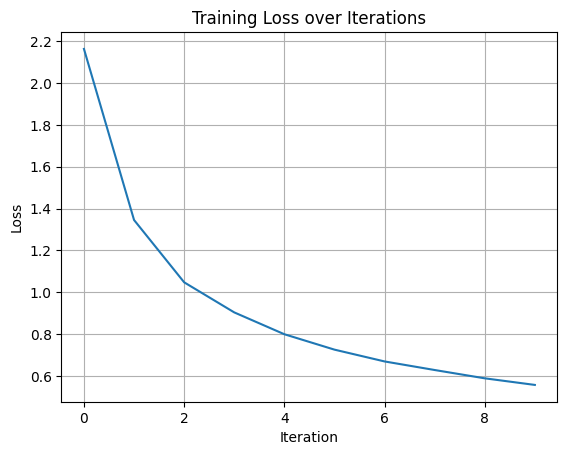

In [22]:
import matplotlib.pyplot as plt
plt.plot(history['train'], label='Train Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss over Iterations')
plt.grid()
plt.show()
# print(